In [3]:
from datascience import *
from datascience.predicates import are
path_data = '../../../../data/'
import numpy as np
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

In [5]:
huck_finn_url = 'https://www.inferentialthinking.com/data/huck_finn.txt'
huck_finn_text = read_url(huck_finn_url)
huck_finn_chapters = huck_finn_text.split("CHAPTER")[44:]

little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[1:]


In [6]:
Table().with_column("Chapters", huck_finn_chapters)

Chapters
I. YOU don't know about me without you have read a book ...
II. WE went tiptoeing along a path amongst the trees ba ...
"III. WELL, I got a good going-over in the morning from ..."
"IV. WELL, three or four months run along, and it was we ..."
V. I had shut the door to. Then I turned around and the ...
"VI. WELL, pretty soon the old man was up and around aga ..."
"VII. ""GIT up! What you 'bout?"" I opened my eyes and loo ..."
VIII. THE sun was up so high when I waked that I judged ...
IX. I wanted to go and look at a place right about the ...
X. AFTER breakfast I wanted to talk about the dead man ...


Text(0.5, 1.08, 'Cumulative Number of times each name appears')

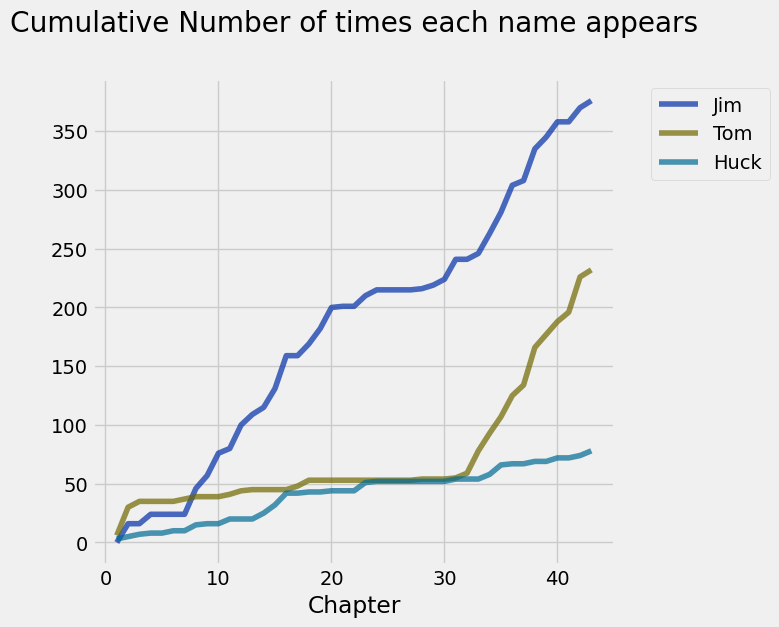

In [8]:
counts = Table().with_columns([
    "Jim", np.cumsum(np.char.count(huck_finn_chapters, "Jim")),
    "Tom", np.cumsum(np.char.count(huck_finn_chapters, "Tom")),
    "Huck", np.cumsum(np.char.count(huck_finn_chapters, "Huck"))
])

# Plotting the cumulative counts: i.e., how many times in each chapter

cum_counts = counts.with_column("Chapter", np.arange(1, 44, 1))
cum_counts.plot(column_for_xticks=3)
plots.title("Cumulative Number of times each name appears", y=1.08)

Jim has a central role and so appears so many times.
Huck barely appears as he's the narrator. Tom came in around chapter 30 and from then on, he's on the roll.

## Little Women by Louisa May Alcott

In [10]:
Table().with_column("Chapters", little_women_chapters)

Chapters
"ONE PLAYING PILGRIMS ""Christmas won't be Christmas witho ..."
TWO A MERRY CHRISTMAS Jo was the first to wake in the gr ...
"THREE THE LAURENCE BOY ""Jo! Jo! Where are you?"" cried Me ..."
"FOUR BURDENS ""Oh, dear, how hard it does seem to take up ..."
"FIVE BEING NEIGHBORLY ""What in the world are you going t ..."
SIX BETH FINDS THE PALACE BEAUTIFUL The big house did pr ...
"SEVEN AMY'S VALLEY OF HUMILIATION ""That boy is a perfect ..."
"EIGHT JO MEETS APOLLYON ""Girls, where are you going?"" as ..."
"NINE MEG GOES TO VANITY FAIR ""I do think it was the most ..."
"TEN THE P.C. AND P.O. As spring came on, a new set of am ..."


In [11]:
# Get the cumulative counts of the names in the chapters of Little Women

counts = Table().with_columns([
        'Amy', np.cumsum(np.char.count(little_women_chapters, 'Amy')),
        'Beth', np.cumsum(np.char.count(little_women_chapters, 'Beth')),
        'Jo', np.cumsum(np.char.count(little_women_chapters, 'Jo')),
        'Meg', np.cumsum(np.char.count(little_women_chapters, 'Meg')),
        'Laurie', np.cumsum(np.char.count(little_women_chapters, 'Laurie')),

    ])

Text(0.5, 1.08, 'Cumulative Number of times each name appears')

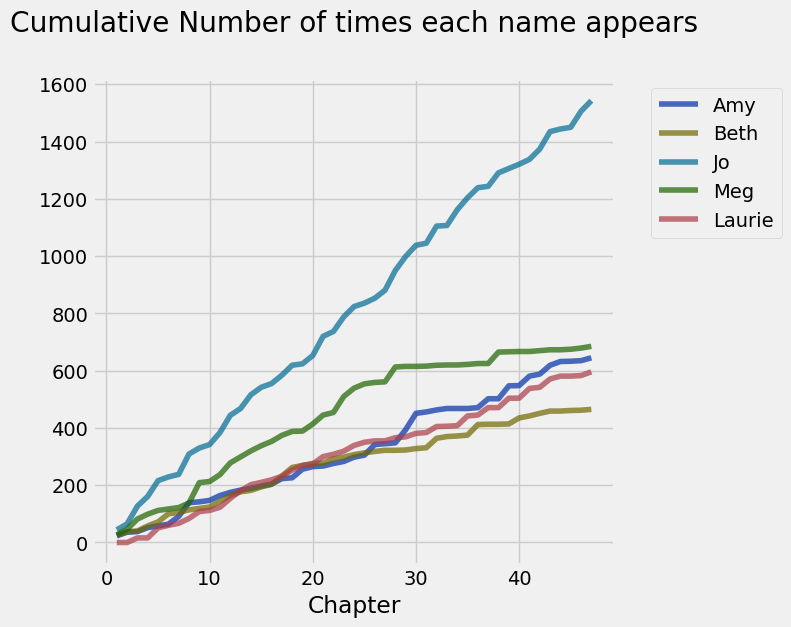

In [13]:
cum_counts = counts.with_column("Chapter", np.arange(1, 48, 1))
cum_counts.plot(column_for_xticks=5)
plots.title("Cumulative Number of times each name appears", y=1.08)

From the plot, one can surmise that something's up with Jo, and guess what.
She's the protagonist!

In [20]:
cum_counts

Amy,Beth,Jo,Meg,Laurie,Chapter
23,26,44,26,0,1
36,38,65,46,0,2
38,40,127,82,16,3
52,58,161,99,16,4
58,72,216,112,51,5
64,100,229,117,60,6
91,105,238,122,67,7
139,114,309,138,84,8
142,119,330,209,108,9
147,124,342,213,112,10


## Another type of character

Here we count the periods and the number of characters in each chapter of our two classics.

In [14]:
chars_periods_huck = Table().with_columns([
    "Huck Finn Chapter Length", [len(s) for s in huck_finn_chapters],
    "Number of Periods", np.char.count(huck_finn_chapters, ".")
])

chars_periods_little_women = Table().with_columns([
    "Little Women Chapter Length", [len(s) for s in little_women_chapters],
    "Number of Periods", np.char.count(little_women_chapters, ".")
])

In [15]:
chars_periods_huck

Huck Finn Chapter Length,Number of Periods
7027,66
11983,117
8530,72
6800,84
8167,91
14551,125
13219,127
22209,249
8082,71
7037,70


In [16]:
chars_periods_little_women

Little Women Chapter Length,Number of Periods
21759,189
22148,188
20558,231
25526,195
23395,255
14622,140
14431,131
22476,214
33767,337
18508,185


Text(0, 0.5, 'Number of characters in chapter')

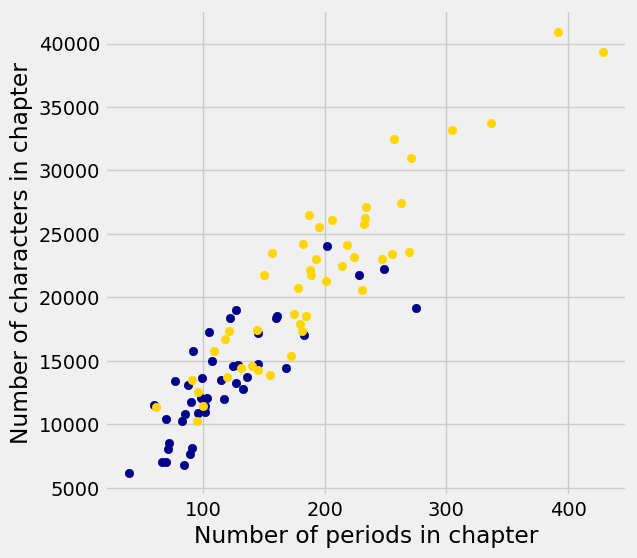

In [18]:
# let's look at both visually
plots.figure(figsize=(6, 6))
plots.scatter(chars_periods_huck.column(1), 
              chars_periods_huck.column(0),
              color="darkblue")
plots.scatter(chars_periods_little_women.column(1), 
              chars_periods_little_women.column(0),
              color="gold")
plots.xlabel("Number of periods in chapter")
plots.ylabel("Number of characters in chapter")

We see that :
- the chapters from _Little Women_ were generally longer than those in _Huckleberry Finn_.
- A huge number of the chapters from both are centered around 100 periods and the 100 - 150k character mark.
- Essentially signaling 100 - 150 characters between periods.